# Создание подписей к изображениям  с помощью трансформеров

В этом блокноте необходимо реализовать основные части декодера трансформера, который создает подписи к изображениям.

In [5]:
# Необходимые установки
import time, os, json
import numpy as np
import matplotlib.pyplot as plt

from dlcv.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from dlcv.transformer_layers import *
from dlcv.captioning_solver_transformer import CaptioningSolverTransformer
from dlcv.classifiers.transformer import CaptioningTransformer
from dlcv.coco_utils import load_coco_data, sample_coco_minibatch, decode_captions
from dlcv.image_utils import image_from_url

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # Размер графика по умолчанию.
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """ возвращает относительную ошибку """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

## Установка h5py

Набор данных COCO, который мы будем использовать, хранится в формате HDF5. Чтобы загружать файлы HDF5, нужно установить пакет `h5py` Python. Из командной строки запустите: <br/>
`pip install h5py` <br/>
Если вы получили ошибку доступа, то может потребоваться выполнить команду от имени пользователя root: <br/>
 `sudo pip install h5py`

Вы также можете запускать команды прямо из  Jupyter notebook, поставив перед командой префикс "!":

Выполните команду, приведенную  ниже в ячейке 

Возможно при установке пакета `h5py` Вы получите сообщения о том,что элементы пакета уже установлены.:<br/>
Requirement already satisfied: h5py in c:\users\hp\anaconda3\envs\python36\lib\site-packages (3.1.0)<br/>
Requirement already satisfied: numpy>=1.12 in c:\users\hp\anaconda3\envs\python36\lib\site-packages (from h5py) (1.19.2)<br/>
Requirement already satisfied: cached-property in c:\users\hp\anaconda3\envs\python36\lib\site-packages (from h5py) (1.5.2)

In [2]:
!pip install h5py

# Датасет Microsoft COCO
В этом задании мы будем использовать  набор данных Microsoft COCO (http://mscoco.org/) 2014 года, который стал стандартным испытательным набором для изображений с субтитрами. Набор данных состоит из 80 000 обучающих изображений и 40 000 проверочных изображений, каждое из которых снабжено 5 подписями.

Объем данных COCO составляет ~ 1 ГБ. Он должен быть загружен в  каталог `dlcv/datasets/coco_captioning` в предварительно обработанном виде (см.ниже). 

Для всех изображений набора данных COCO  были извлечены признаки на уровне fc7 для сети VGG-16, предварительно обученной на данных ImageNet. Чтобы уменьшить время обработки и снизить требования к памяти,  размерность признаков  была сокращена с 4096 до 512 путем сжатия с использованием метода главных компонент; эти признаки были сохранены в файлах `train2014_vgg16_fc7_pca.h5` и `val2014_vgg16_fc7_pca.h5`.

Исходные изображения взяты из системы Flickr. URL-адреса обучающих и проверочных изображений хранятся в файлах `train2014_urls.txt` и` val2014_urls.txt`, соответственно. Это позволяет загружать изображения на лету для визуализации. Поскольку изображения загружаются на лету, **вы должны быть подключены к Интернету для просмотра изображений**.

Работа со строками неэффективна, поэтому мы будем работать с кодированной версией подписи к изображению. Каждому слову присваивается целочисленный идентификатор, что позволяет нам представлять подписи изображений последовательностью целых чисел. Таблица соответствия между целочисленными идентификаторами и словами находится в файле `coco2014_vocab.json`. Вы можете использовать функцию `decode_captions` из файла `dlcv / coco_utils.py` для преобразования массивов целочисленных идентификаторов обратно в строки.

Есть пара специальных токенов (лексем), которые добавлены в словарь. Это специальный токен `<START>` и  токен `<END>`, которые добавляются в начало и конец каждого заголовка изображения, соответственно. Редкие слова заменяются специальным токеном `<UNK>`  ("unknown"- «неизвестно»). Кроме того, поскольку при обучении используются  мини-блоки, содержащие заголовки различной длины, то короткие подписи дополняются специальным токеном `<NULL>` после токена `<END>` и   для `<NULL>` токенов не вычисляются потери или градиенты.  Так как обработка специальных токенов создает некоторые сложности, то Вам предлагается готовое решение, которое избавит Вас от необходимости писать соответствующий код.

Вы можете загрузить все данные MS-COCO (заголовки, функции, URL-адреса и словарь), используя функцию `load_coco_data` из файла` dlcv/ coco_utils.py`. Запустите ниже ячейку блокнота, чтобы сделать это:

In [6]:
# Загрузка данных COCO c диска; функция возвращает словарь
# В этом блокноте будем работать  только c сокращенной размерностью признаков (512), т.е. флаг pca_features=True 
data = load_coco_data(pca_features=True)

# Печать названий ключей, типов значений словаря данных, размеров и типов данных
for k, v in data.items():
    if type(v) == np.ndarray:
        print(k, type(v), v.shape, v.dtype)
    else:
        print(k, type(v), len(v))

base dir  C:\Users\HP\DL_lab\2026_transformer_реш\dlcv\datasets/coco_captioning
train_captions <class 'numpy.ndarray'> (400135, 17) int32
train_image_idxs <class 'numpy.ndarray'> (400135,) int32
val_captions <class 'numpy.ndarray'> (195954, 17) int32
val_image_idxs <class 'numpy.ndarray'> (195954,) int32
train_features <class 'numpy.ndarray'> (82783, 512) float32
val_features <class 'numpy.ndarray'> (40504, 512) float32
idx_to_word <class 'list'> 1004
word_to_idx <class 'dict'> 1004
train_urls <class 'numpy.ndarray'> (82783,) <U63
val_urls <class 'numpy.ndarray'> (40504,) <U63


# Трансформер
Как вы уже поняли, RNN невероятно мощные, но часто они медленно обучаемы. Кроме того, RNN с трудом кодируют длинные зависимости в элементах данных, которые находятся друг от друга на больших расстояниях (хотя LSTM — несколько смягчают эту проблему).

В 2017 году Васвани и др. представили архитектуру "Трансформер" в статье ["Attention Is All You Need"](https://arxiv.org/abs/1706.03762), чтобы а) ввести параллелизм и б) позволить моделям обучаться длинным зависимостям в данных. Статья не только привела к появлению известных моделей в области обработки естественного языка, таких как BERT и GPT , но и к взрывному интересу применения трансформеров в различных областях, включая зрение. Хотя здесь мы рассмотрим модель для формирования подписей к изображениям, сама идея учета внимания при обучении нейросетей гораздо более общая.

# Трансформер: Многоголовое внимание (multi-headed attention)

### Внимание как скалярное произведение

Напомним, что внимание может рассматриваться как операция над запросом $q\in\mathbb{R}^d$, множеством векторов значений $\{v_1,\dots,v_n\},v_i\in\mathbb{R}^d$, и множеством векторов ключей $\{k_1,\dots,k_n\}, k_i \in \mathbb{R}^d$, которая определяется выражением:


\begin{align}
c = \sum_{i=1}^{n} v_i \alpha_i ;    \  \alpha_i = \frac{\exp(k_i^\top q)}{\sum_{j=1}^{n} \exp(k_j^\top q)}  \\
\end{align}

где $\alpha_i$ обычно называют "весами внимания", а результат операции  $c\in\mathbb{R}^d$ представляет взвешенное среднее векторов значений.

### Самовнимание
В Трансформерах выполняется операция самовнимания, которая означает, что значения (values), ключи (keys) и запросы (query) формируются на основе входных данных $X \in \mathbb{R}^{\ell \times d}$, где $\ell$ длина последовательности. При этом мы обучаем матрицы параметров $V,K,Q \in \mathbb{R}^{d\times d}$, чтобы обеспечить  отображение входа $X$ соответственно в векторы значений, ключей и запрсов: 

\begin{align}
v_i = Vx_i\ \ i \in \{1,\dots,\ell\}\\
k_i = Kx_i\ \ i \in \{1,\dots,\ell\}\\
q_i = Qx_i\ \ i \in \{1,\dots,\ell\}
\end{align}

### Масштабированное многоголовое внимание в  виде скалярного произведения

В случае многоголового внимания мы обучаем матрицы параметров для каждой головы, это позволяет модели лучше акцентировать внимание на различных частях входных данных. Пусть $h$  - число голов, и $Y_i$ выходное внимание головы $i$. Здесь мы обучаем отдельные матрицы $Q_i$, $K_i$ и $V_i$. Для того, чтобы сохранить схему вычислений, такой же как и для одно-голового внимания, мы выбираем $Q_i \in \mathbb{R}^{d\times d/h}$, $K_i \in \mathbb{R}^{d\times d/h}$ and $V_i \in \mathbb{R}^{d\times d/h}$. Складывая и масштабируя  $\frac{1}{\sqrt{d/h}}$ скалярное произведение в нашей простой модели внимания, получим

\begin{equation} \label{qkv_eqn}
Y_i = \text{softmax}\bigg(\frac{(XQ_i)(XK_i)^\top}{\sqrt{d/h}}\bigg)(XV_i)
\end{equation}

где $Y_i\in\mathbb{R}^{\ell \times d/h}$ и $\ell$ - длина последовательности.

В нашей реализации мы применяем регуляризацию `dropout` к весам внимания (хотя на практике её можно использовать на любом этапе):

\begin{equation} \label{qkvdropout_eqn}
Y_i = \text{dropout}\bigg(\text{softmax}\bigg(\frac{(XQ_i)(XK_i)^\top}{\sqrt{d/h}}\bigg)\bigg)(XV_i)
\end{equation}

Окончательно, выход модуля самовнимания является линейным преобразованием $A$ oбъединенных выходов голов $Y_i$:

\begin{equation}
Y = [Y_1;\dots;Y_h]A
\end{equation}

где $A \in\mathbb{R}^{d\times d}$ и $[Y_1;\dots;Y_h]\in\mathbb{R}^{\ell \times d}$.

Реализуйте многоголовое внимание на основе масштабированного скалярного произведения в классе  `MultiHeadAttention` в файле `dlcv/transformer_layers.py`. Код ниже обеспечит проверку вашей реализации. Относительная ошибка должна быть менее e-3`.

In [7]:
torch.manual_seed(231)
# Выбирайте измерения так, чтобы они все были уникальными для упрощения отладки:
# В частности, ниже выбраны следующие значения N=1, H=2, T=3, D//H=4 и D=8.

batch_size = 1
sequence_length = 3
embed_dim = 8
attn = MultiHeadAttention(embed_dim, num_heads=2)

# Самовнимание
data = torch.randn(batch_size, sequence_length, embed_dim)
self_attn_output = attn(query=data, key=data, value=data)

# Маскированное самовнимание
mask = torch.randn(sequence_length, sequence_length) < 0.5
masked_self_attn_output = attn(query=data, key=data, value=data, attn_mask=mask)

# Внимание на основе 2-х разных входов
other_data = torch.randn(batch_size, sequence_length, embed_dim)
attn_output = attn(query=data, key=other_data, value=other_data)

# ожидаемые значения самовнимания
expected_self_attn_output = np.asarray([[
[-0.2494,  0.1396,  0.4323, -0.2411, -0.1547,  0.2329, -0.1936,
          -0.1444],
         [-0.1997,  0.1746,  0.7377, -0.3549, -0.2657,  0.2693, -0.2541,
          -0.2476],
         [-0.0625,  0.1503,  0.7572, -0.3974, -0.1681,  0.2168, -0.2478,
          -0.3038]]])

# ожидаемые значения маскированного самовнимания
expected_masked_self_attn_output = np.asarray([[
[-0.1347,  0.1934,  0.8628, -0.4903, -0.2614,  0.2798, -0.2586,
          -0.3019],
         [-0.1013,  0.3111,  0.5783, -0.3248, -0.3842,  0.1482, -0.3628,
          -0.1496],
         [-0.2071,  0.1669,  0.7097, -0.3152, -0.3136,  0.2520, -0.2774,
          -0.2208]]])

# ожидаемые значения внимания на основе 2-х разных входов
expected_attn_output = np.asarray([[
[-0.1980,  0.4083,  0.1968, -0.3477,  0.0321,  0.4258, -0.8972,
          -0.2744],
         [-0.1603,  0.4155,  0.2295, -0.3485, -0.0341,  0.3929, -0.8248,
          -0.2767],
         [-0.0908,  0.4113,  0.3017, -0.3539, -0.1020,  0.3784, -0.7189,
          -0.2912]]])

print('ошибка самовнимания: ', rel_error(expected_self_attn_output, self_attn_output.detach().numpy()))
print('ошибка маскированного самовнимания: ', rel_error(expected_masked_self_attn_output, masked_self_attn_output.detach().numpy()))
print('ошибка внимания: ', rel_error(expected_attn_output, attn_output.detach().numpy()))

ошибка самовнимания:  0.0003775124598178026
ошибка маскированного самовнимания:  0.00015258647520338531
ошибка внимания:  0.00035202796492688154


# Позиционное кодирование 

Хотя трансформеры способны акцентировать внимание на любой части входных данных, механизм внимания не имеет понятия о порядке следования токенов. Для многих задач (особенно обработки естественного языка) относительный порядок токенов очень важен. Чтобы обеспечить учет порядка следования токенов, в схему трансформера добавляют позиционное кодирование при  встраивании отдельных токенов.

Определим матрицу $P \in \mathbb{R}^{l\times d}$, где $P_{ij} = $

$$
\begin{cases}
\text{sin}\left(i \cdot 10000^{-\frac{j}{d}}\right) & \text{если j четное} \\
\text{cos}\left(i \cdot 10000^{-\frac{(j-1)}{d}}\right) & \text{иначе} \\
\end{cases}
$$

Вместо того, чтобы напрямую подавать на вход нейросети  $X \in \mathbb{R}^{l\times d}$, на её вход подают $X + P$.

Реализуйте этот слой в  классе `PositionalEncoding` в файле `dlcv/transformer_layers.py`. С помощью кода ниже протестируйте вашу реализацию. Вы должны получить ошибку порядка `e-3` или менее.

In [8]:
torch.manual_seed(231)

batch_size = 1
sequence_length = 2
embed_dim = 6
data = torch.randn(batch_size, sequence_length, embed_dim)

pos_encoder = PositionalEncoding(embed_dim)
output = pos_encoder(data)

expected_pe_output = np.asarray([[[-1.2340,  1.1127,  1.6978, -0.0865, -0.0000,  1.2728],
                                  [ 0.9028, -0.4781,  0.5535,  0.8133,  1.2644,  1.7034]]])

print('ошибка позиционного кодирования: ', rel_error(expected_pe_output, output.detach().numpy()))

ошибка позиционного кодирования:  0.00010421011374914356


# Вопрос 1

Выше мы представили несколько ключевых решений, которые были положены в основу при проектировании масштабированного внимания в виде скалярного произведения. Объясните, почему следующие решения были выгодны:

1. Использование нескольких голов внимания вместо одной.
2. Деление на $\sqrt{d/h}$ перед применением функции softmax. Вспомните, что $d$ — это размерность признака, а $h$ — это количество голов внимания.
3. Применение линейного преобразования к выходным данным операции внимания.

Необходимо дать краткий ответ по каждому пункту, но обязательно будьте конкретны в описании того, что произошло бы без каждой данной детали реализации, почему такая ситуация была бы неоптимальной и как предлагаемая реализация улучшает ситуацию.

**Ваш ответ:** 




# Трансформер для подписи изображений

Теперь, когда вы реализовали  слои, описанные выше, вы можете объединить их для создания модели, обеспечивающей формирование подписей к изображениям с  использованием  трансформера. Откройте файл `dlcv/classifiers/transformer.py` и просмотрите класс `CaptioningTransformer`.

Реализуйте в классе функцию `forward`. После этого выполните проверку прямого распространения используя небольшой тест ниже. Вы должна получить относительную ошибку `e-5` или менее.

In [9]:
torch.manual_seed(231)
np.random.seed(231)

N, D, W = 4, 20, 30
word_to_idx = {'<NULL>': 0, 'cat': 2, 'dog': 3}
V = len(word_to_idx)
T = 3

transformer = CaptioningTransformer(
    word_to_idx,
    input_dim=D,
    wordvec_dim=W,
    num_heads=2,
    num_layers=2,
    max_length=30
)

# Выбираем фиксированные значения для всех параметров модели
for p in transformer.parameters():
    p.data = torch.tensor(np.linspace(-1.4, 1.3, num=p.numel()).reshape(*p.shape))

features = torch.tensor(np.linspace(-1.5, 0.3, num=(N * D)).reshape(N, D))
captions = torch.tensor((np.arange(N * T) % V).reshape(N, T))

scores = transformer(features, captions)

expected_scores = np.asarray([[[-16.9532,   4.8261,  26.6054],
         [-17.1033,   4.6906,  26.4844],
         [-15.0708,   4.1108,  23.2924]],
        [[-17.1767,   4.5897,  26.3562],
         [-15.6017,   4.8693,  25.3403],
         [-15.1028,   4.6905,  24.4839]],
        [[-17.2172,   4.7701,  26.7574],
         [-16.6755,   4.8500,  26.3754],
         [-17.2172,   4.7701,  26.7574]],
        [[-16.3669,   4.1602,  24.6872],
         [-16.7897,   4.3467,  25.4831],
         [-17.0103,   4.7775,  26.5652]]])

print('ошибка scores: ', rel_error(expected_scores, scores.detach().numpy()))

ошибка scores:  5.056720614342753e-06


# Переобучение модели трансформера на небольшом объеме данных

Выполните переобучение модели трансформера, формирующего подписи к изображениям, на том же небольшом наборе данных. 
В этом задании используется класс `CaptioningSolverTransformer` для обучения моделей, формирующих подписи к изображениям. 

Выполните ячеку ниже, чтобы убедиться, что  модель переобучается на небольшом наборе из 100 обучающих примеров. 

base dir  C:\Users\HP\DL_lab\2026_transformer_реш\dlcv\datasets/coco_captioning
(Iteration 1 / 200) loss: 5.023861
(Iteration 11 / 200) loss: 2.838942
(Iteration 21 / 200) loss: 1.969251
(Iteration 31 / 200) loss: 1.578352
(Iteration 41 / 200) loss: 1.207504
(Iteration 51 / 200) loss: 1.058034
(Iteration 61 / 200) loss: 0.727213
(Iteration 71 / 200) loss: 0.659099
(Iteration 81 / 200) loss: 0.443693
(Iteration 91 / 200) loss: 0.345755
(Iteration 101 / 200) loss: 0.264495
(Iteration 111 / 200) loss: 0.122238
(Iteration 121 / 200) loss: 0.089583
(Iteration 131 / 200) loss: 0.081036
(Iteration 141 / 200) loss: 0.064176
(Iteration 151 / 200) loss: 0.059066
(Iteration 161 / 200) loss: 0.037873
(Iteration 171 / 200) loss: 0.041521
(Iteration 181 / 200) loss: 0.021156
(Iteration 191 / 200) loss: 0.021602


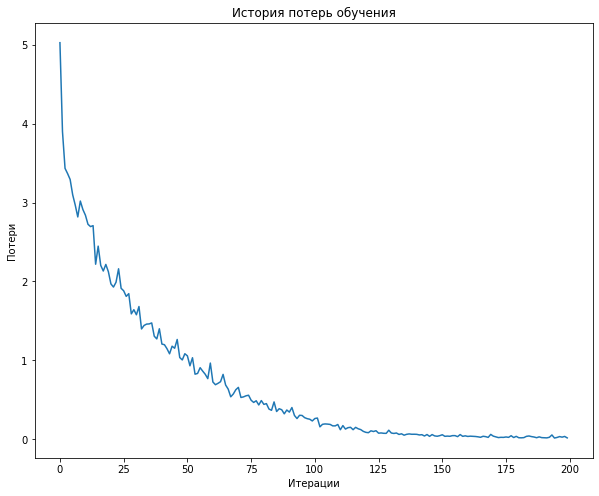

In [13]:
torch.manual_seed(231)
np.random.seed(231)

# загрузка данных (50 обучающих примеров)
data = load_coco_data(max_train=50)

# создание Трансформера для формирования заголовков
transformer = CaptioningTransformer(
          word_to_idx=data['word_to_idx'],
          input_dim=data['train_features'].shape[1],
          wordvec_dim=256,
          num_heads=2,
          num_layers=2,
          max_length=30
        )

# создание экземпляра класса для обучения Трансформера
transformer_solver = CaptioningSolverTransformer(transformer, data, idx_to_word=data['idx_to_word'],
           num_epochs=100,
           batch_size=25,
           learning_rate=0.001,
           verbose=True, print_every=10,
         )
# обучение  трансформера
transformer_solver.train()

# Построение графика потерь
plt.plot(transformer_solver.loss_history)
plt.xlabel('Итерации')
plt.ylabel('Потери')
plt.title('История потерь обучения')
plt.show()

Печать финальных потерь обучения. Вы должны получить финальные потери обучения меньше, чем 0.03.

In [8]:
print('Финальные потери: ', transformer_solver.loss_history[-1])

Финальные потери:  0.019136833


# Тестирование трансформера

Модели, формирующие  подписи ведут себя по-разному во время обучения и во время тестирования. Во время обучения у нас есть доступ к истинному заголовку, поэтому мы вводим истинные слова в качестве выходных данных модели на каждом этапе. Во время тестирования мы предсказваем слово на отдельном временном шаге и подаем это слово на вход модели на следующем временном шаге.

Выполните ячейку ниже, чтобы получить заголовки на выходе переобученной модели как для  обучающих изображений, так и для проверочных. Подписи для  обучающих изображениях должны быть очень хорошими;  для проверочных изображений они, вероятно, не будут иметь смысла.

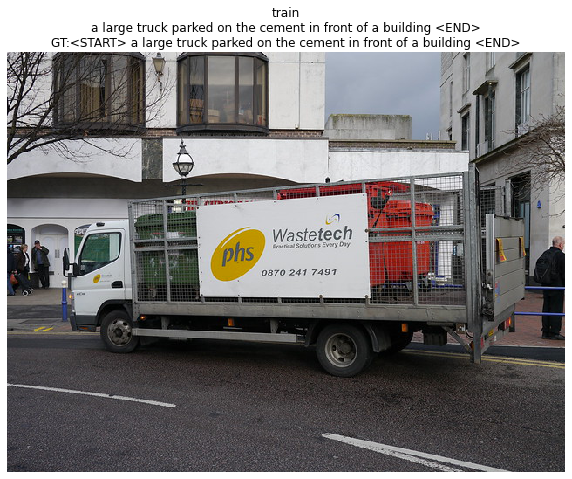

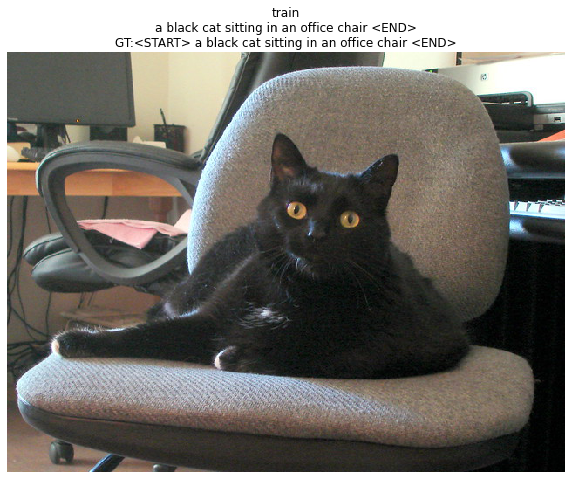

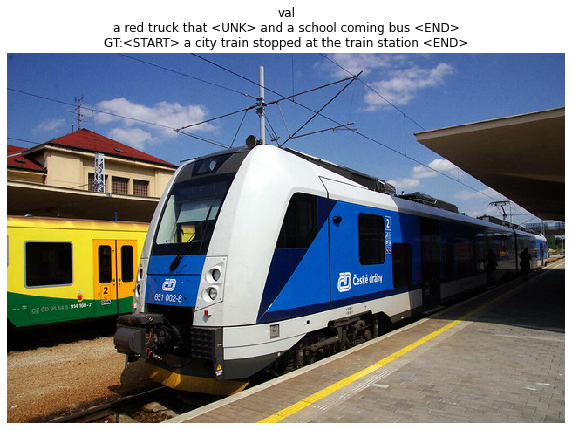

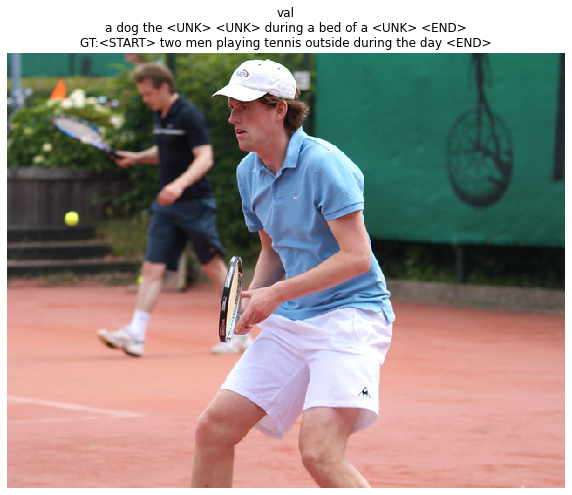

In [17]:
# Если вы получили ошибку "URL не найден" не волнуйтесь!
# Вы можете повторно выполнить ячейку столько раз, сколько захотите.
for split in ['train', 'val']:
    minibatch = sample_coco_minibatch(data, split=split, batch_size=2)
    gt_captions, features, urls = minibatch
    gt_captions = decode_captions(gt_captions, data['idx_to_word'])

    sample_captions = transformer.sample(features, max_length=30)
    sample_captions = decode_captions(sample_captions, data['idx_to_word'])

    for gt_caption, sample_caption, url in zip(gt_captions, sample_captions, urls):
        img = image_from_url(url)
        # Пропустить отсутсвующий URLs.
        if img is None: continue
        plt.imshow(img)            
        plt.title('%s\n%s\nGT:%s' % (split, sample_caption, gt_caption))
        plt.axis('off')
        plt.show()